In [34]:
import sqlite3
con = sqlite3.connect("Chinook_Sqlite.sqlite")
cur = con.cursor()

import pandas as pd

total_sales = cur.execute('''
    SELECT i.billingcountry, sum(total) AS 'TotalSales'
    FROM invoice AS i
    GROUP BY billingcountry
    ORDER BY totalsales DESC
    '''
)

country, total = total_sales.fetchone()
print(f"The highest grossing country is {country} with a total of {total}")


The highest grossing country is USA with a total of 523.06


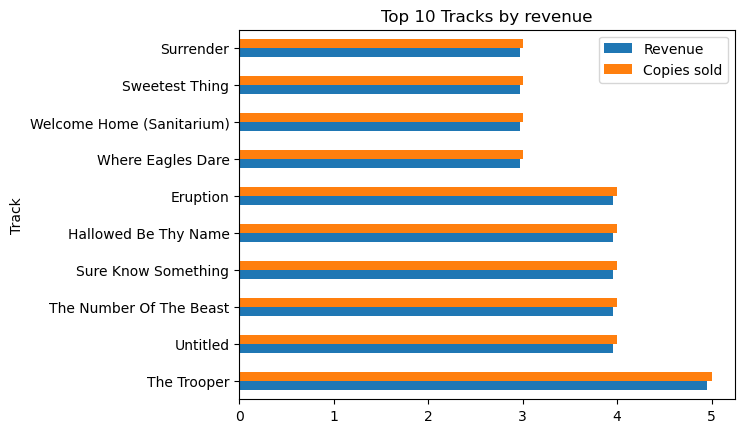

In [82]:
import sqlite3
con = sqlite3.connect("Chinook_Sqlite.sqlite")
cur = con.cursor()

import pandas as pd

import numpy as np

top_artists = cur.execute('''
    SELECT t.Name, sum(il.UnitPrice), SUM(il.Quantity) AS TotalQuantitySold
    FROM Track as t
    LEFT JOIN InvoiceLine AS il ON t.TrackId = il.TrackId
    GROUP BY t.Name
    ORDER BY TotalQuantitySold DESC
    LIMIT 10;
    '''
                         )


df = pd.DataFrame(top_artists)
print(df)
df.columns = ["Track", "Revenue", "Copies sold"]
ax = df.plot(kind="barh", x="Track", title="Top 10 Tracks by revenue")
